# SHAP Interpretability for Linear Models

**Docker image**: `ml4t`

**Purpose**: use SHAP (SHapley Additive exPlanations) to interpret a Ridge
regression model trained on the ETF panel. For linear models, SHAP values
decompose exactly into $\phi_j = \beta_j \cdot (x_j - \bar{x}_j)$, making
attributions transparent and verifiable.

We demonstrate four layers of interpretation:

1. **Global feature importance** - which features matter most across all predictions.
2. **Individual forecast explanation** - how features combine for a single prediction.
3. **Decision-relevant analysis** - SHAP profiles for *right* vs *wrong*
   high-magnitude predictions.
4. **Stability** - cross-fold importance trajectories + within-fold bootstrap
   confidence bands on the top features' mean $|\phi_j|$.

**Learning objectives**

- Compute and verify exact linear SHAP values for Ridge
- Explain a single forecast via SHAP waterfall decomposition
- Compare feature drivers for correct vs incorrect high-conviction predictions
- Build a SHAP stability chart and bootstrap confidence bands within a fold

**Book reference**: Section 11.4 - Inside the Black Box: Model
Interpretability with SHAP.

**Prerequisites**

- Ch7 21-day forward return labels at `case_studies/etfs/labels/fwd_ret_21d.parquet`
- Ch8 ETF features at `case_studies/etfs/features/financial.parquet`
- `02_regularization_paths` (Ridge / LASSO context)

**Downstream**: Ch12 extends to tree-based models via `TreeExplainer`; Ch13
applies KernelSHAP to deep learning.

## Setup

In [1]:
"""SHAP Interpretability for Linear Models - decompose Ridge predictions into per-feature attributions."""

import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import shap
from ml4t.diagnostic.metrics import compute_ic_hac_stats, cross_sectional_ic_series
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

from utils.cv_splits import generate_cv_splits
from utils.paths import display_path, get_case_study_dir, get_chapter_dir, get_output_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, show_with_alt

warnings.filterwarnings("ignore")

In [2]:
SEED = 42
MAX_SYMBOLS = 0
MAX_CV_FOLDS = 0
RETRAIN = False
ARTIFACT_TAG = ""

In [3]:
RANDOM_SEED = SEED
LABEL_HORIZON_SESSIONS = (
    21  # the forward window in the label, and the overlap the t-stat must absorb
)
set_global_seeds(SEED)

## Load Features and Labels

We use the same ETF features (Ch8) and 21-day forward returns (Ch7) as
`02_regularization_paths`, spanning momentum, volatility, volume and
cross-asset families.

In [4]:
CASE_DIR = get_case_study_dir("etfs")
FEATURES_PATH = CASE_DIR / "features" / "financial.parquet"
LABELS_PATH = CASE_DIR / "labels" / "fwd_ret_21d.parquet"

assert FEATURES_PATH.exists(), (
    f"Features not found: {FEATURES_PATH}\nRun the Ch8 ETF features notebook first."
)
assert LABELS_PATH.exists(), (
    f"Labels not found: {LABELS_PATH}\nRun the Ch7 ETF labels notebook first."
)

features_df = pl.read_parquet(FEATURES_PATH).with_columns(pl.col("timestamp").cast(pl.Date))
labels_df = pl.read_parquet(LABELS_PATH).with_columns(pl.col("timestamp").cast(pl.Date))

In [5]:
TARGET_COL = "fwd_ret_21d"
ASSET_COL = "symbol"

df = features_df.join(labels_df, on=["timestamp", ASSET_COL], how="inner")

META_COLS = {"timestamp", ASSET_COL, TARGET_COL}
FEATURE_COLS = sorted(c for c in df.columns if c not in META_COLS)

# Drop features that are entirely null (can happen with reduced test universes)
all_null = [c for c in FEATURE_COLS if df[c].null_count() == df.height]
if all_null:
    print(f"Dropping {len(all_null)} all-null features: {all_null}")
    df = df.drop(all_null)
    FEATURE_COLS = [c for c in FEATURE_COLS if c not in all_null]

# Replace inf/NaN with null, then drop all nulls
df = df.with_columns(
    [
        pl.when(pl.col(c).is_nan() | pl.col(c).is_infinite())
        .then(None)
        .otherwise(pl.col(c))
        .alias(c)
        for c in FEATURE_COLS
    ]
)
df = df.drop_nulls(subset=FEATURE_COLS + [TARGET_COL]).sort(["timestamp", ASSET_COL])

if MAX_SYMBOLS > 0:
    assets = df[ASSET_COL].unique().sort().head(MAX_SYMBOLS).to_list()
    df = df.filter(pl.col(ASSET_COL).is_in(assets))

print(f"Shape: {df.height:,} rows x {len(FEATURE_COLS)} features")
print(f"Assets: {df[ASSET_COL].n_unique()}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")

Shape: 402,446 rows x 57 features
Assets: 99
Date range: 2007-01-04 to 2025-12-01


## Walk-Forward CV: Select Last Fold

SHAP analysis requires a single trained model and its corresponding test set.
We use the **last fold** of the walk-forward protocol (most recent test period),
which gives us the model trained on the most data and the most realistic
out-of-sample evaluation.

In [6]:
splits = generate_cv_splits(df, case_study_id="etfs", label_buffer="21D", date_col="timestamp")

features_array = df.select(FEATURE_COLS).to_numpy()
target_array = df[TARGET_COL].to_numpy()
dates_np = df["timestamp"].to_numpy()
assets_np = df[ASSET_COL].to_numpy()

cv_splits = []
for s in splits:
    tr_start, tr_end = np.datetime64(s["train_start"]), np.datetime64(s["train_end"])
    te_start, te_end = np.datetime64(s["val_start"]), np.datetime64(s["val_end"])
    train_idx = np.where((dates_np >= tr_start) & (dates_np <= tr_end))[0]
    test_idx = np.where((dates_np >= te_start) & (dates_np <= te_end))[0]
    cv_splits.append((train_idx, test_idx))

if MAX_CV_FOLDS > 0 and len(cv_splits) > MAX_CV_FOLDS:
    cv_splits = cv_splits[:MAX_CV_FOLDS]
    splits = splits[:MAX_CV_FOLDS]

# Use last fold
train_idx, test_idx = cv_splits[-1]
last_split = splits[-1]

print(f"Last fold (fold {len(cv_splits)}):")
print(
    f"  Train: {last_split['train_start']} to {last_split['train_end']} ({len(train_idx):,} samples)"
)
print(f"  Test:  {last_split['val_start']} to {last_split['val_end']} ({len(test_idx):,} samples)")

Last fold (fold 8):
  Train: 2007-01-04 00:00:00 to 2015-11-24 00:00:00 (165,105 samples)
  Test:  2015-12-28 00:00:00 to 2016-12-23 00:00:00 (22,184 samples)


## Train Ridge Model and Compute SHAP Values

We fit Ridge on the training fold and compute SHAP values on the test set. The
penalty is deliberately light, set in the cell below: the point here is the
attribution machinery, and a lightly penalized model spreads weight across
more features, which makes the decomposition easier to read. It is not the
penalty `02_regularization_paths` found best for prediction on this panel, and
the attributions below describe the model that was fitted rather than the one
that would be traded.
`shap.LinearExplainer` gives **exact** SHAP values for linear models - no
approximation, no sampling.

**SHAP API pattern** (v0.50+): Create a masker to describe the background
distribution, pass it to the explainer, then call the explainer on the test
data to get an `Explanation` object containing `.values`, `.base_values`,
and `.data` in a single structure.

In [7]:
MODELS_DIR = get_chapter_dir(11) / "models" / "05_shap_analysis"
is_reduced_run = MAX_SYMBOLS > 0 or MAX_CV_FOLDS > 0
if is_reduced_run and not ARTIFACT_TAG:
    ARTIFACT_TAG = "_fast"

RESULTS_PATH = MODELS_DIR / f"shap_results{ARTIFACT_TAG}.joblib"
NEED_TRAINING = RETRAIN or not RESULTS_PATH.exists()

In [8]:
if NEED_TRAINING:
    scaler = StandardScaler()
    X_train = scaler.fit_transform(features_array[train_idx])
    X_test = scaler.transform(features_array[test_idx])
    y_train = target_array[train_idx]
    y_test = target_array[test_idx]

    model = Ridge(alpha=1.0, random_state=RANDOM_SEED)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"Ridge trained on {len(y_train):,} samples, predicting {len(y_test):,}.")

### SHAP Computation (Last Fold)

In [9]:
if NEED_TRAINING:
    # Independent masker assumes feature independence → SHAP = coef * (x - mean).
    # max_samples defaults to 100, which would make that mean a 100-row subsample and
    # leave the closed-form check below disagreeing in the third decimal. The whole
    # point of the section is that linear SHAP is exact given the true background
    # expectation, so the background is the full training set.
    masker = shap.maskers.Independent(X_train, max_samples=len(X_train))
    explainer = shap.LinearExplainer(model, masker)
    explanation = explainer(X_test)
    shap_values = explanation.values
    expected_value = float(explanation.base_values[0])
    print(f"SHAP values computed: {shap_values.shape}")

### SHAP Stability: All Folds

Train Ridge on every fold and compute mean |SHAP| per feature. This reveals
whether the model learns consistent feature importance across time periods.

In [10]:
if NEED_TRAINING:
    fold_importance = {}
    for fold_i, (tr_idx, te_idx) in enumerate(cv_splits):
        sc_f = StandardScaler()
        X_tr_f = sc_f.fit_transform(features_array[tr_idx])
        X_te_f = sc_f.transform(features_array[te_idx])
        m_f = Ridge(alpha=1.0, random_state=RANDOM_SEED)
        m_f.fit(X_tr_f, target_array[tr_idx])
        exp_f = shap.LinearExplainer(m_f, shap.maskers.Independent(X_tr_f))
        fold_importance[fold_i + 1] = np.mean(np.abs(exp_f(X_te_f).values), axis=0)
    print(f"Computed SHAP stability across {len(fold_importance)} folds.")

    MODELS_DIR.mkdir(parents=True, exist_ok=True)
    joblib.dump(
        {
            "model": model,
            "scaler": scaler,
            "X_train": X_train,
            "X_test": X_test,
            "y_train": y_train,
            "y_test": y_test,
            "y_pred": y_pred,
            "shap_values": shap_values,
            "expected_value": expected_value,
            "fold_importance": fold_importance,
        },
        RESULTS_PATH,
    )
    print("Cached results saved.")

### Load Cached Results

When pre-computed artifacts exist, restore all arrays and reconstruct the
SHAP `Explanation` object (joblib caches raw arrays, not SHAP objects).

In [11]:
if not NEED_TRAINING:
    _cached = joblib.load(RESULTS_PATH)
    model = _cached["model"]
    scaler = _cached["scaler"]
    X_train = _cached["X_train"]
    X_test = _cached["X_test"]
    y_train = _cached["y_train"]
    y_test = _cached["y_test"]
    y_pred = _cached["y_pred"]
    shap_values = _cached["shap_values"]
    expected_value = _cached["expected_value"]
    fold_importance = _cached.get("fold_importance")
    del _cached

    # Reconstruct Explanation - joblib caches arrays, not SHAP objects
    explanation = shap.Explanation(
        values=shap_values,
        base_values=np.full(len(shap_values), expected_value),
        data=X_test,
        feature_names=FEATURE_COLS,
    )

### Recompute Stale Artifacts

The cache is stale if it was produced with fewer folds (e.g. a TEST run)
or against a different data vintage - when the feature/label tables are
regenerated the test fold's row count changes, so a cached `y_pred` no
longer aligns with the current `test_idx`. Either condition triggers a
refit on the full split set and a recompute of per-fold SHAP importance.

In [12]:
_cache_fold_stale = fold_importance is not None and len(fold_importance) < len(cv_splits)
_cache_data_stale = len(y_pred) != len(test_idx) or X_test.shape[0] != len(test_idx)
if not NEED_TRAINING and (_cache_fold_stale or _cache_data_stale):
    print(
        "Cached SHAP artifacts are stale (fold count or data vintage changed); recomputing full artifacts."
    )
    scaler = StandardScaler()
    X_train = scaler.fit_transform(features_array[train_idx])
    X_test = scaler.transform(features_array[test_idx])
    y_train = target_array[train_idx]
    y_test = target_array[test_idx]

    model = Ridge(alpha=1.0, random_state=RANDOM_SEED)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    masker = shap.maskers.Independent(X_train)
    explainer = shap.LinearExplainer(model, masker)
    explanation = explainer(X_test)
    shap_values = explanation.values
    expected_value = float(explanation.base_values[0])

    fold_importance = {}
    for fold_i, (tr_idx, te_idx) in enumerate(cv_splits):
        sc_f = StandardScaler()
        X_tr_f = sc_f.fit_transform(features_array[tr_idx])
        X_te_f = sc_f.transform(features_array[te_idx])
        m_f = Ridge(alpha=1.0, random_state=RANDOM_SEED)
        m_f.fit(X_tr_f, target_array[tr_idx])
        exp_f = shap.LinearExplainer(m_f, shap.maskers.Independent(X_tr_f))
        fold_importance[fold_i + 1] = np.mean(np.abs(exp_f(X_te_f).values), axis=0)

    MODELS_DIR.mkdir(parents=True, exist_ok=True)
    joblib.dump(
        {
            "model": model,
            "scaler": scaler,
            "X_train": X_train,
            "X_test": X_test,
            "y_train": y_train,
            "y_test": y_test,
            "y_pred": y_pred,
            "shap_values": shap_values,
            "expected_value": expected_value,
            "fold_importance": fold_importance,
        },
        RESULTS_PATH,
    )
    print("Cached results updated.")

### Persist SHAP Arrays for Downstream Figures

Writes the arrays behind the figures above to
`output/05_shap_analysis/shap_arrays.npz`: the SHAP values, the test matrix,
predictions and outcomes, the base value, the feature names and the per-fold
importance matrix. The book's Figure 11.3 is generated from this file, which
is why it is written in a plain `.npz` a reader can open with `np.load`
without installing the SHAP toolchain.

In [13]:
SHAP_ARRAYS_PATH = get_output_dir(11, "05_shap_analysis") / "shap_arrays.npz"
fold_ids_sorted = sorted(fold_importance) if fold_importance is not None else []
fold_importance_matrix = (
    np.array([fold_importance[k] for k in fold_ids_sorted], dtype=np.float32)
    if fold_ids_sorted
    else np.zeros((0, len(FEATURE_COLS)), dtype=np.float32)
)
np.savez(
    SHAP_ARRAYS_PATH,
    shap_values=shap_values.astype(np.float32),
    X_test=X_test.astype(np.float32),
    y_pred=y_pred.astype(np.float32),
    y_test=y_test.astype(np.float32),
    expected_value=np.float32(expected_value),
    feature_names=np.asarray(FEATURE_COLS, dtype=np.str_),
    fold_ids=np.array(fold_ids_sorted, dtype=np.int32),
    fold_importance=fold_importance_matrix,
)
print(f"Persisted SHAP arrays to {display_path(SHAP_ARRAYS_PATH)}")

Persisted SHAP arrays to 11_ml_pipeline/output/05_shap_analysis/shap_arrays.npz


In [14]:
dates_test = dates_np[test_idx]
symbols_test = assets_np[test_idx]

pred_df = pl.DataFrame({"timestamp": dates_test, "symbol": symbols_test, "prediction": y_pred})
ret_df = pl.DataFrame({"timestamp": dates_test, "symbol": symbols_test, "forward_return": y_test})
ic_per_date = cross_sectional_ic_series(
    pred_df,
    ret_df,
    pred_col="prediction",
    ret_col="forward_return",
    date_col="timestamp",
    entity_col="symbol",
)
ic_clean = ic_per_date.drop_nans("ic").drop_nulls("ic").sort("timestamp")
ic = float(ic_clean["ic"].mean())
n_periods = ic_clean.height
ic_stats = compute_ic_hac_stats(ic_clean, ic_col="ic", label_horizon=LABEL_HORIZON_SESSIONS)

print(f"Test set: {len(y_test):,} samples ({n_periods} dates)")
print(f"IC (cross-sectional Spearman, mean across dates): {ic:.4f}")
print(f"IC t-stat, HAC:   {ic_stats['t_stat']:.2f}  (p = {ic_stats['p_value']:.3f})")
print(f"IC t-stat, naive: {ic_stats['naive_t_stat']:.2f}  (treats dates as independent)")
print(f"SHAP values shape: {shap_values.shape}")

Test set: 22,184 samples (252 dates)
IC (cross-sectional Spearman, mean across dates): 0.0216
IC t-stat, HAC:   0.50  (p = 0.615)
IC t-stat, naive: 1.38  (treats dates as independent)
SHAP values shape: (22184, 57)


## Verify: SHAP Matches Coefficient Attribution

For a linear model, each SHAP value is exactly the coefficient times the
feature's deviation from its background mean:

$$\phi_j^{(i)} = \beta_j \cdot \bigl(x_j^{(i)} - \bar{x}_j\bigr)$$

This makes linear SHAP transparent - every attribution can be checked by hand,
and the cell below finds the two agree to float precision. The identity holds
because the background here is the whole training set, so $\bar{x}_j$ in the
formula is the mean the library integrates over. A subsampled background is
what would put a gap between them: `shap.maskers.Independent` defaults to a
hundred rows, and at that setting these two disagree in the second decimal.
Ch12 contrasts this with tree-based models where SHAP requires algorithmic
computation.

In [15]:
coef_attribution = model.coef_ * (X_test - X_train.mean(axis=0))

corr = np.corrcoef(shap_values.ravel(), coef_attribution.ravel())[0, 1]
max_diff = np.max(np.abs(shap_values - coef_attribution))
mean_abs_diff = np.mean(np.abs(shap_values - coef_attribution))

print(f"Correlation (SHAP vs coef*deviation): {corr:.6f}")
print(f"Mean |difference|: {mean_abs_diff:.2e}")
print(f"Max |difference|:  {max_diff:.2e}")
print("\nLinear SHAP is transparent: attributions match the closed-form solution.")

Correlation (SHAP vs coef*deviation): 1.000000
Mean |difference|: 0.00e+00
Max |difference|:  0.00e+00

Linear SHAP is transparent: attributions match the closed-form solution.


## Global Feature Importance

The beeswarm plot ranks features by mean $|\phi_j|$ across all test samples.
Each dot is one prediction: its x-position shows the SHAP value (impact on
predicted return), and color shows the feature value (red = high, blue = low).
This reveals both *which* features matter and *how* they affect predictions.

In [16]:
# Ensure feature names are set (numpy arrays don't carry column names)
explanation.feature_names = FEATURE_COLS

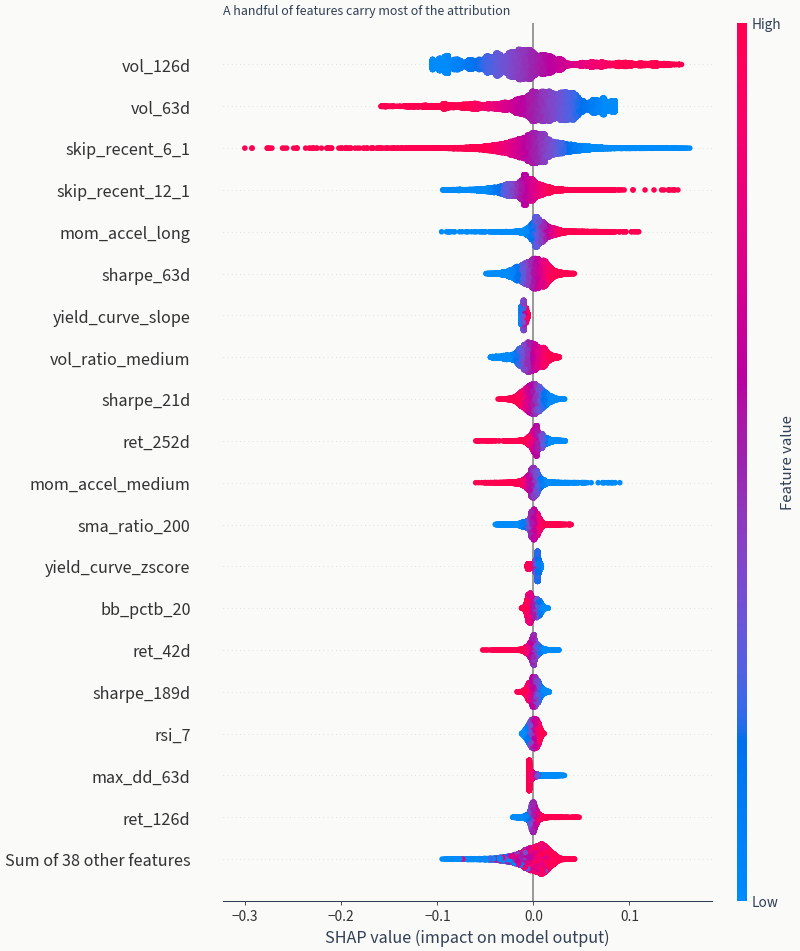

In [17]:
shap.plots.beeswarm(explanation, max_display=20, show=False)
plt.title("A handful of features carry most of the attribution")
show_with_alt(
    plt.gcf(),
    "SHAP beeswarm: one row per feature ordered by mean absolute attribution, one "
    "dot per prediction, positioned by its SHAP value and coloured by feature value.",
)

### Mean |SHAP| by Feature

The bar chart provides a simpler summary - mean absolute SHAP value per
feature, equivalent to the average *magnitude* of each feature's contribution
to predictions.

In [18]:
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
importance = pl.DataFrame({"feature": FEATURE_COLS, "mean_abs_shap": mean_abs_shap}).sort(
    "mean_abs_shap", descending=True
)
importance.head(15)

feature,mean_abs_shap
str,f64
"""vol_126d""",0.038719
"""vol_63d""",0.033863
"""skip_recent_6_1""",0.023502
"""skip_recent_12_1""",0.017613
"""mom_accel_long""",0.01066
…,…
"""mom_accel_medium""",0.005524
"""sma_ratio_200""",0.004944
"""yield_curve_zscore""",0.004374


### Sign Consistency Check

The first layer of economic narrative building: do learned coefficients have
the expected sign? A model where momentum has a negative coefficient or
volatility a positive one is likely fitting noise.

In [19]:
# Expected signs for key features (based on factor theory)
EXPECTED_SIGNS = {
    "ret_21d": "+",  # short-term momentum
    "ret_63d": "+",  # medium-term momentum
    "ret_126d": "+",  # long-term momentum
    "vol_21d": "-",  # short-term volatility (risk)
    "vol_63d": "-",  # medium-term volatility
    "obv_zscore_63d": "+",  # volume confirms trend
}

coefs = dict(zip(FEATURE_COLS, model.coef_, strict=False))
sign_check = pl.DataFrame(
    [
        {
            "feature": feat,
            "expected": sign,
            "actual": "+" if coefs.get(feat, 0) >= 0 else "-",
            "coefficient": coefs.get(feat, 0),
            "consistent": (sign == "+") == (coefs.get(feat, 0) >= 0),
        }
        for feat, sign in EXPECTED_SIGNS.items()
        if feat in coefs
    ]
)
sign_check

feature,expected,actual,coefficient,consistent
str,str,str,f64,f64
"""ret_21d""","""+""","""+""",0.000674,1.0
"""ret_63d""","""+""","""-""",-0.000094,0.0
"""ret_126d""","""+""","""+""",0.006172,1.0
"""vol_21d""","""-""","""-""",-0.004334,1.0
"""vol_63d""","""-""","""-""",-0.063808,1.0
"""obv_zscore_63d""","""+""","""-""",-0.002874,0.0


Sign violations are not necessarily wrong - Ridge splits credit across
correlated features, so a feature may flip sign if a correlated partner
absorbs its effect. But persistent violations across folds warrant investigation.

### Feature Dependence

For a linear model, the SHAP dependence plot is linear by construction
($\phi_j = \beta_j \cdot (x_j - \bar{x}_j)$). We show it here to establish
the pattern - Ch12 extends this to tree models where dependence reveals
threshold effects and non-linear interactions.

The feature plotted is the highest-importance one that actually varies on this
test fold. A feature that is near-constant over the window has near-constant
attribution too, and its dependence plot reduces to a single point.

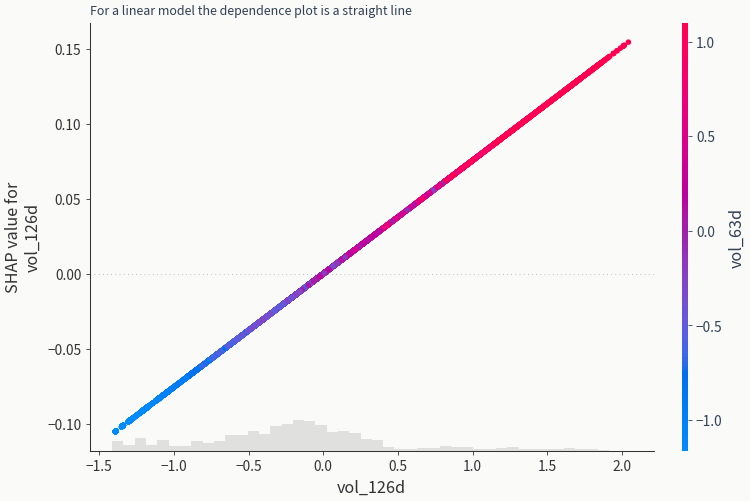

In [20]:
dep_feature = None
for feat in importance["feature"].to_list():
    idx = FEATURE_COLS.index(feat)
    if np.std(X_test[:, idx]) > 1e-8 and np.std(shap_values[:, idx]) > 1e-12:
        dep_feature = feat
        break

if dep_feature is None:
    dep_feature = importance["feature"][0]

top_idx_dep = FEATURE_COLS.index(dep_feature)
color_feature = importance["feature"][1] if len(importance) > 1 else dep_feature
color_idx = FEATURE_COLS.index(color_feature)

shap.plots.scatter(
    explanation[:, top_idx_dep],
    color=explanation[:, color_idx],
    show=False,
)
ax = plt.gca()
ax.set_title("For a linear model the dependence plot is a straight line")
show_with_alt(
    plt.gcf(),
    "Scatter of one feature's SHAP value against its own value, coloured by a "
    "second feature, forming a straight line.",
)

## Individual Forecast Explanation

SHAP waterfall plots decompose a *single* prediction into feature contributions.
Starting from the expected value (population mean prediction), each feature
pushes the prediction up (red) or down (blue) by its SHAP value.

We show two examples: one where the model made a large positive prediction
that turned out correct, and one where a large prediction was wrong.

In [21]:
# Find a high-conviction correct prediction
signed_error = y_pred - y_test
correct_sign = np.sign(y_pred) == np.sign(y_test)

# High positive prediction that was correct
candidates_right = np.where(correct_sign & (y_pred > np.percentile(y_pred, 95)))[0]
example_right = candidates_right[0]

# High positive prediction that was wrong
candidates_wrong = np.where(~correct_sign & (y_pred > np.percentile(y_pred, 95)))[0]
example_wrong = candidates_wrong[0] if len(candidates_wrong) > 0 else np.where(~correct_sign)[0][0]

--- Correct high-conviction prediction ---
  Predicted: +0.0205  Actual: +0.0057
  Date: 2016-01-04  Asset: EWT


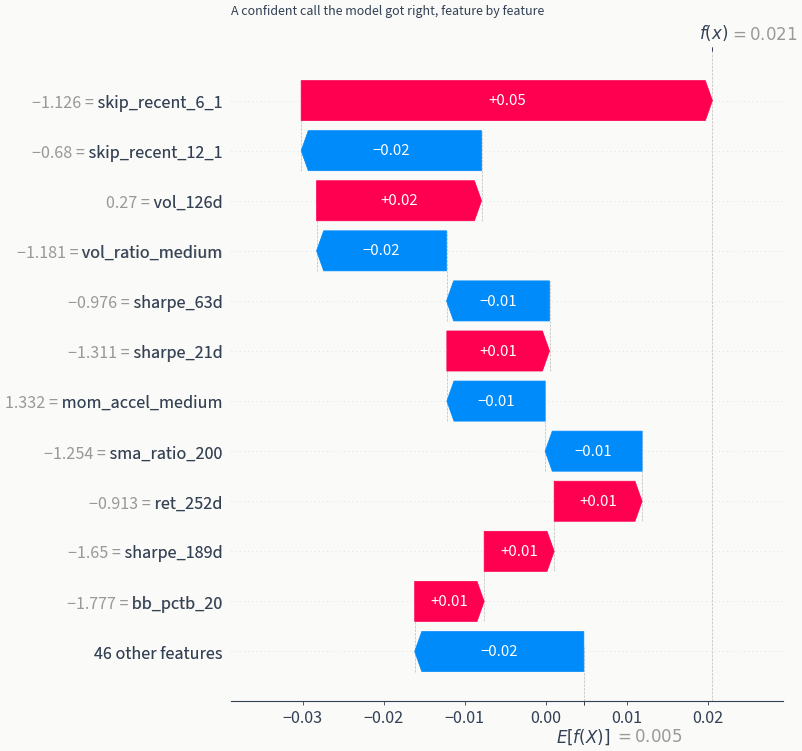

In [22]:
print("--- Correct high-conviction prediction ---")
print(f"  Predicted: {y_pred[example_right]:+.4f}  Actual: {y_test[example_right]:+.4f}")
print(f"  Date: {dates_np[test_idx[example_right]]}  Asset: {assets_np[test_idx[example_right]]}")

fig, ax = plt.subplots(figsize=(8, 6))
shap.plots.waterfall(explanation[example_right], max_display=12, show=False)
plt.title("A confident call the model got right, feature by feature")
show_with_alt(
    plt.gcf(),
    "Waterfall of one prediction: bars for each feature's contribution, running "
    "from the base value to the predicted return.",
)

--- Incorrect high-conviction prediction ---
  Predicted: +0.0212  Actual: -0.1165
  Date: 2015-12-28  Asset: EWH


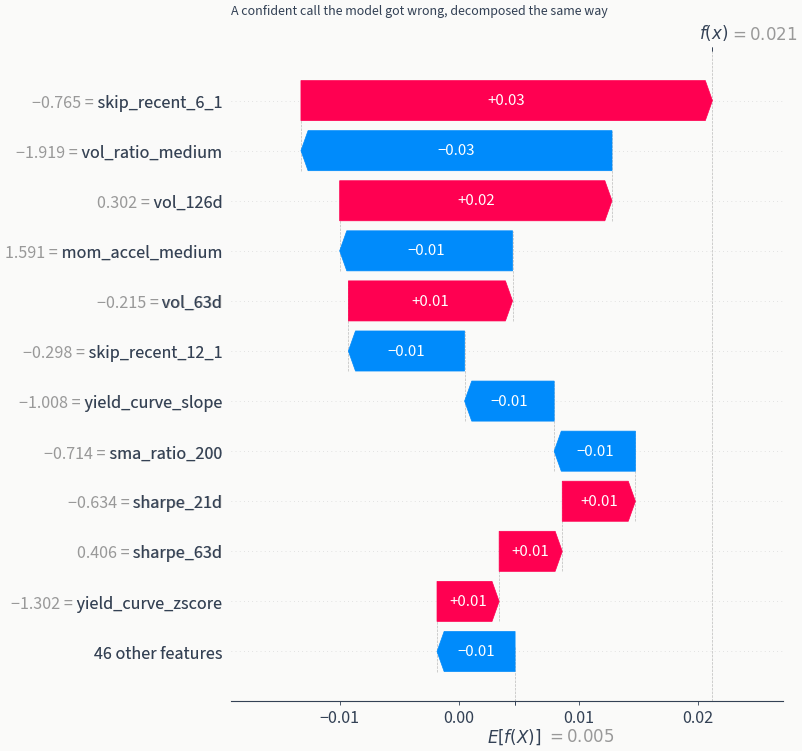

In [23]:
print("--- Incorrect high-conviction prediction ---")
print(f"  Predicted: {y_pred[example_wrong]:+.4f}  Actual: {y_test[example_wrong]:+.4f}")
print(f"  Date: {dates_np[test_idx[example_wrong]]}  Asset: {assets_np[test_idx[example_wrong]]}")

fig, ax = plt.subplots(figsize=(8, 6))
shap.plots.waterfall(explanation[example_wrong], max_display=12, show=False)
plt.title("A confident call the model got wrong, decomposed the same way")
show_with_alt(
    plt.gcf(),
    "Waterfall of one prediction: bars for each feature's contribution, running "
    "from the base value to the predicted return.",
)

The waterfall plots show the same model making confident calls for different
reasons. Comparing the feature attributions gives a first hint at what
distinguishes correct from incorrect predictions - the systematic analysis
below makes this rigorous.

## Decision-Relevant Predictions: Right vs Wrong

Not all predictions are equally important. In a portfolio context, predicted
return magnitude maps directly to position size ($w_i \propto \hat{y}_i$), so
predictions with large $|\hat{y}|$ are **decision-relevant** - they drive the
biggest bets and have the greatest impact on PnL.

We isolate the highest-conviction predictions, the top band by $|\hat{y}|$ set
in the cell below, and split them into:

- **Right**: $\text{sign}(\hat{y}) = \text{sign}(y)$ - the model was
  confidently correct
- **Wrong**: $\text{sign}(\hat{y}) \neq \text{sign}(y)$ - the model was
  confidently incorrect

Comparing their SHAP profiles reveals which features *systematically* mislead
the model at the moments that matter most.

In [24]:
conviction = np.abs(y_pred)
threshold = np.percentile(conviction, 80)
high_mag_mask = conviction >= threshold

correct_mask = np.sign(y_pred) == np.sign(y_test)
right_mask = high_mag_mask & correct_mask
wrong_mask = high_mag_mask & ~correct_mask

n_high = high_mag_mask.sum()
n_right = right_mask.sum()
n_wrong = wrong_mask.sum()

print(f"High-magnitude predictions (top 20%): {n_high:,}")
print(f"  Right (correct sign): {n_right:,} ({n_right / n_high:.0%})")
print(f"  Wrong (incorrect sign): {n_wrong:,} ({n_wrong / n_high:.0%})")
print("\nMean |predicted return|:")
print(f"  Right: {np.mean(np.abs(y_pred[right_mask])):.4f}")
print(f"  Wrong: {np.mean(np.abs(y_pred[wrong_mask])):.4f}")
print("Mean actual return:")
print(f"  Right: {np.mean(y_test[right_mask]):+.4f}")
print(f"  Wrong: {np.mean(y_test[wrong_mask]):+.4f}")

High-magnitude predictions (top 20%): 4,437
  Right (correct sign): 1,842 (42%)
  Wrong (incorrect sign): 2,595 (58%)

Mean |predicted return|:
  Right: 0.0235
  Wrong: 0.0230
Mean actual return:
  Right: -0.0026
  Wrong: +0.0214


Read the right/wrong split before reading anything below it. If the model is
wrong on more than half of its largest bets, the SHAP comparison that follows
is a diagnosis of what misleads it, not evidence that it has skill where it is
most confident. Attribution explains what a model did; it says nothing about
whether the model was right, and a confident wrong prediction has just as
clean a decomposition as a confident correct one.

### SHAP Profiles: Right vs Wrong

We compute the mean |SHAP| per feature for each group. Features where the
"wrong" group has disproportionately high SHAP are candidates for improvement:
the model relied on them heavily, but they led it astray.

In [25]:
shap_right = shap_values[right_mask]
shap_wrong = shap_values[wrong_mask]

mean_shap_right = np.mean(np.abs(shap_right), axis=0)
mean_shap_wrong = np.mean(np.abs(shap_wrong), axis=0)

comparison = pl.DataFrame(
    {
        "feature": FEATURE_COLS,
        "shap_all": mean_abs_shap,  # Reuse from global importance above
        "shap_right": mean_shap_right,
        "shap_wrong": mean_shap_wrong,
        "wrong_vs_right": mean_shap_wrong / np.maximum(mean_shap_right, 1e-10),
    }
).sort("wrong_vs_right", descending=True)

print(
    "Features ranked by wrong/right SHAP ratio (high ratio = feature drives more of the wrong predictions):"
)
comparison.head(15)

Features ranked by wrong/right SHAP ratio (high ratio = feature drives more of the wrong predictions):


feature,shap_all,shap_right,shap_wrong,wrong_vs_right
str,f64,f64,f64,f64
"""hurst_100""",0.00236,0.002351,0.003122,1.327616
"""yield_curve_zscore""",0.004374,0.004015,0.004567,1.137351
"""vol_21d""",0.002441,0.003143,0.003443,1.095284
"""chop_14""",0.000023,0.000025,0.000027,1.091295
"""vol_ratio_21d""",0.002355,0.002487,0.002683,1.078497
…,…,…,…,…
"""regime""",0.002237,0.002237,0.002237,1.0
"""vol_ratio_short""",0.000728,0.000813,0.000804,0.988711
"""vol_63d""",0.033863,0.04931,0.047739,0.968145


A ratio above one means the feature contributed more to the mistakes than to
the successes: the model leaned on it hardest when it was wrong. If volume or
cross-asset features dominate the top of this list,
they may be unreliable as standalone predictors and could benefit from
interaction terms or non-linear modeling in Ch12.

### Visualizing the Difference

The bar chart compares mean |SHAP| for the top features, side by side for
right (correct) and wrong (incorrect) high-magnitude predictions.

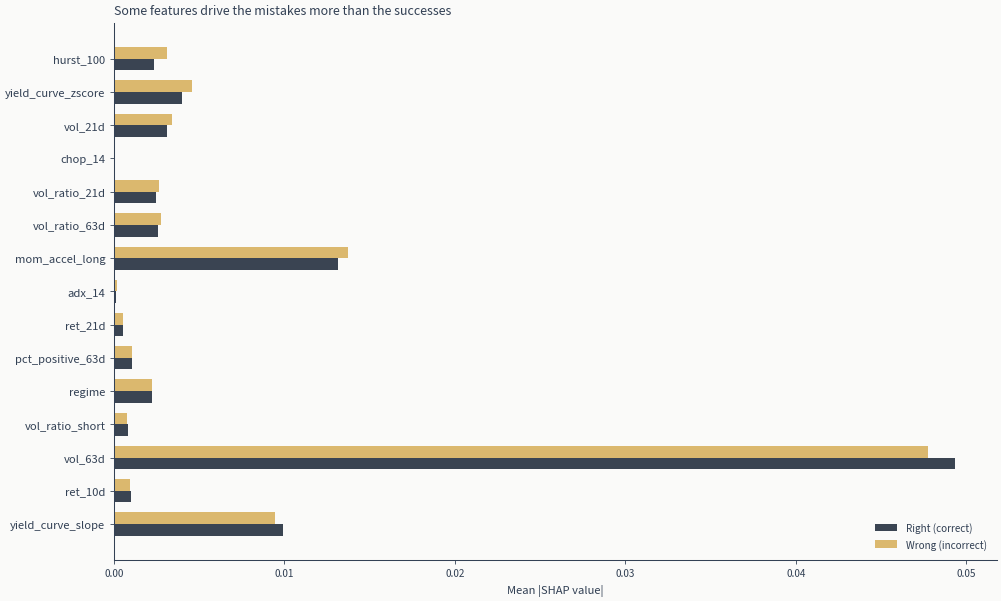

In [26]:
top_features = comparison.head(15)["feature"].to_list()
top_idx = [FEATURE_COLS.index(f) for f in top_features]

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(top_features))
width = 0.35

right_vals = [mean_shap_right[i] for i in top_idx]
wrong_vals = [mean_shap_wrong[i] for i in top_idx]

ax.barh(x + width / 2, right_vals, width, label="Right (correct)", alpha=0.8)
ax.barh(x - width / 2, wrong_vals, width, label="Wrong (incorrect)", alpha=0.8)

ax.set_yticks(x)
ax.set_yticklabels(top_features, fontsize=9)
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Some features drive the mistakes more than the successes")
ax.legend(loc="lower right")
ax.invert_yaxis()
show_with_alt(
    fig,
    "Paired horizontal bars of mean absolute SHAP per feature, one bar for the "
    "correct high-conviction predictions and one for the incorrect ones.",
)

**Interpretation**: Features where the "wrong" bar substantially exceeds the "right"
bar are the model's weak points at high conviction - it relied on them heavily when
making its biggest mistakes. These features are candidates for re-engineering
(e.g., adding interaction terms) or non-linear modeling in Ch12.

### Signed SHAP: Direction of Influence

Mean |SHAP| shows *magnitude*, but the *sign* matters too. A feature that
consistently pushes predictions in the wrong direction is more problematic
than one that adds noise symmetrically.

We compute mean signed SHAP for each group to see directional bias.

In [27]:
mean_signed_right = np.mean(shap_right, axis=0)
mean_signed_wrong = np.mean(shap_wrong, axis=0)

signed_comparison = pl.DataFrame(
    {
        "feature": FEATURE_COLS,
        "signed_shap_right": mean_signed_right,
        "signed_shap_wrong": mean_signed_wrong,
        "direction_diff": mean_signed_wrong - mean_signed_right,
    }
).sort("direction_diff", descending=True)

print("Signed SHAP: features with largest direction difference (wrong - right):")
print(
    "Positive = feature pushed wrong predictions UP more than right ones; negative = the reverse."
)
signed_comparison.head(10)

Signed SHAP: features with largest direction difference (wrong - right):
Positive = feature pushed wrong predictions UP more than right ones; negative = the reverse.


feature,signed_shap_right,signed_shap_wrong,direction_diff
str,f64,f64,f64
"""vol_ratio_medium""",-0.001673,0.000823,0.002496
"""vol_63d""",0.000183,0.002256,0.002073
"""mom_accel_medium""",-0.001614,-0.000148,0.001466
"""mom_accel_long""",0.009671,0.010617,0.000946
"""rsi_7""",0.000037,0.000946,0.000909
"""max_dd_126d""",0.000004,0.000656,0.000652
"""cci_21""",0.000224,0.000848,0.000624
"""ret_126d""",-0.00059,-0.00007,0.00052
"""yield_curve_slope""",-0.00994,-0.009436,0.000504


In [28]:
signed_comparison.tail(10)

feature,signed_shap_right,signed_shap_wrong,direction_diff
str,f64,f64,f64
"""ret_42d""",-0.001113,-0.001643,-0.00053
"""vol_21d""",0.000607,0.000033,-0.000574
"""obv_zscore_63d""",-0.000132,-0.000932,-0.0008
"""bb_pctb_20""",-0.000347,-0.001181,-0.000833
"""max_dd_63d""",-0.000295,-0.001165,-0.00087
"""yield_curve_zscore""",0.002433,0.00156,-0.000873
"""hurst_100""",0.000057,-0.001476,-0.001533
"""skip_recent_6_1""",0.0072,0.005427,-0.001773
"""sharpe_21d""",0.000272,-0.002253,-0.002525


**Interpretation**: Large positive direction differences mean the feature pushed wrong
predictions upward more than right ones - a systematic directional bias at the moments
that matter most. Features with large negative differences show the opposite pattern.
Both directions suggest the feature's signal is unreliable under high conviction.

### Concentration Risk

When a single feature dominates the total SHAP attribution, the prediction
hinges on one input, which is a fragile basis for a trade. The cell below flags
any prediction where one feature accounts for more than the concentration
threshold it sets.

In [29]:
total_abs = np.abs(shap_values).sum(axis=1)
max_abs = np.abs(shap_values).max(axis=1)
max_frac = max_abs / np.maximum(total_abs, 1e-10)
concentrated = max_frac > 0.60

print(
    f"Predictions with >60% concentration: {concentrated.sum():,} / {len(max_frac):,} ({concentrated.mean():.1%})"
)
print(f"Mean max-feature fraction: {max_frac.mean():.1%}")
print(f"95th percentile: {np.percentile(max_frac, 95):.1%}")

Predictions with >60% concentration: 0 / 22,184 (0.0%)
Mean max-feature fraction: 18.8%
95th percentile: 31.3%


Compare the flagged count with the mean and 95th-percentile shares printed
above. A threshold that flags nothing is telling you the threshold is wrong
for this model, not that the risk is absent: on this panel this fitted Ridge
puts a mean of 19% and a 95th percentile of 31% on its largest single feature,
so a cut at 60% could not fire. That is what these coefficients on this data
do, not something the penalty guarantees - a single large coefficient can
still dominate a row's attribution. Where the counts come back
empty, either raise the aggregation to the top three features or compare the
distribution against another model rather than against a fixed cut.
In a fold dominated by a regime change, the same diagnostic can flip and
flag many predictions; checking it per fold is part of the standing
pipeline rather than a one-time exercise.

### Example Waterfall: Typical Right vs Typical Wrong

To make the comparison concrete, we pick the *median* high-magnitude
prediction from each group and show its SHAP waterfall.

In [30]:
# Median by |predicted return| within each group
right_indices = np.where(right_mask)[0]
wrong_indices = np.where(wrong_mask)[0]

right_by_mag = right_indices[np.argsort(np.abs(y_pred[right_indices]))]
wrong_by_mag = wrong_indices[np.argsort(np.abs(y_pred[wrong_indices]))]

median_right = right_by_mag[len(right_by_mag) // 2]
median_wrong = wrong_by_mag[len(wrong_by_mag) // 2]

--- Median high-magnitude RIGHT prediction ---
  Predicted: -0.0211  Actual: -0.0099
  Asset: MCHI


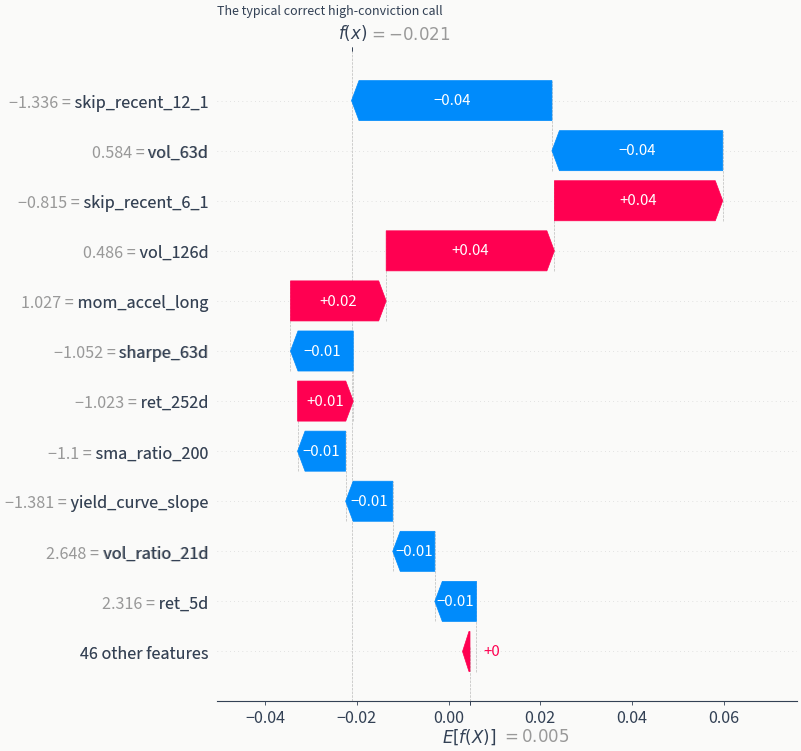

In [31]:
print("--- Median high-magnitude RIGHT prediction ---")
print(f"  Predicted: {y_pred[median_right]:+.4f}  Actual: {y_test[median_right]:+.4f}")
print(f"  Asset: {assets_np[test_idx[median_right]]}")

fig, ax = plt.subplots(figsize=(8, 6))
shap.plots.waterfall(explanation[median_right], max_display=12, show=False)
plt.title("The typical correct high-conviction call")
show_with_alt(
    plt.gcf(),
    "Waterfall of the median correct high-magnitude prediction, one bar per feature.",
)

--- Median high-magnitude WRONG prediction ---
  Predicted: -0.0211  Actual: +0.0199
  Asset: OIH


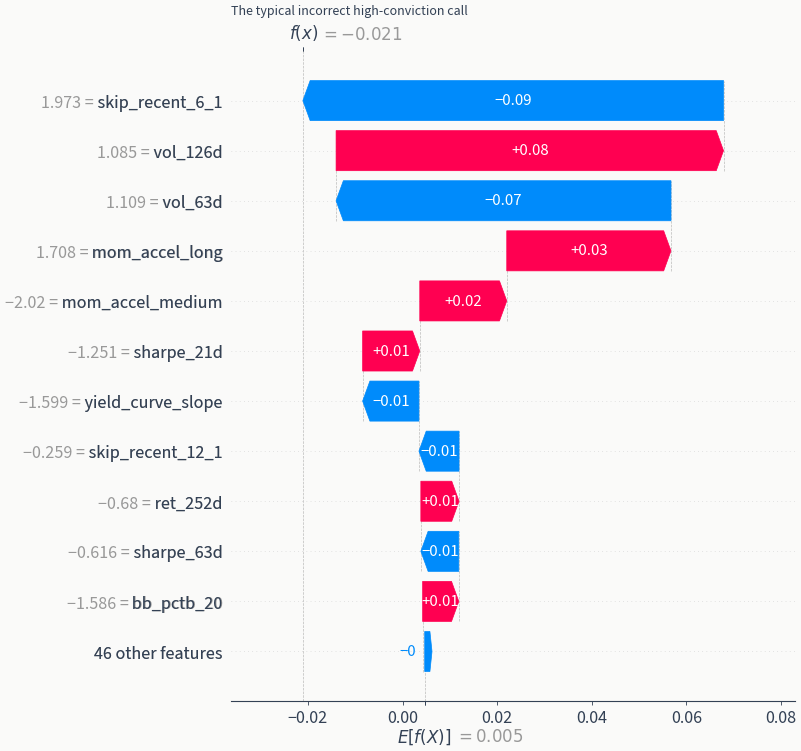

In [32]:
print("--- Median high-magnitude WRONG prediction ---")
print(f"  Predicted: {y_pred[median_wrong]:+.4f}  Actual: {y_test[median_wrong]:+.4f}")
print(f"  Asset: {assets_np[test_idx[median_wrong]]}")

fig, ax = plt.subplots(figsize=(8, 6))
shap.plots.waterfall(explanation[median_wrong], max_display=12, show=False)
plt.title("The typical incorrect high-conviction call")
show_with_alt(
    plt.gcf(),
    "Waterfall of the median incorrect high-magnitude prediction, one bar per feature.",
)

## SHAP Stability Across Folds

A model that learns different feature rankings in each fold is less trustworthy
than one with stable importance. We train Ridge on all 8 walk-forward folds
and track mean |SHAP| for the top features - a key validation diagnostic.

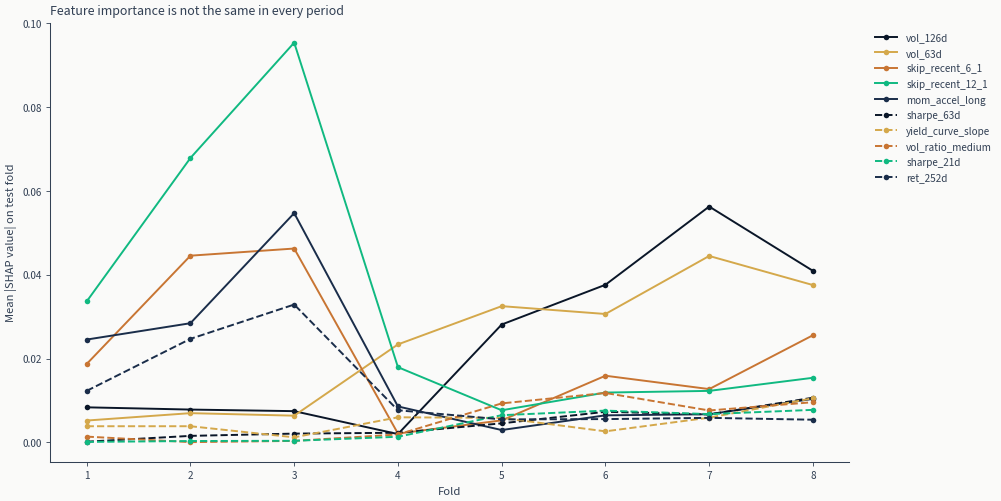

In [33]:
if fold_importance is not None:
    top_stab = importance["feature"].head(10).to_list()
    top_stab_idx = [FEATURE_COLS.index(f) for f in top_stab]
    # 5 distinguishable hues × 2 linestyles → 10 unique combinations,
    # greyscale-readable via the linestyle dimension.
    stab_palette = [
        COLORS["blue"],
        COLORS["amber"],
        COLORS["copper"],
        COLORS["positive"],
        COLORS["slate"],
    ]
    linestyles = ["-", "--"]

    fig, ax = plt.subplots(figsize=(10, 5))
    for i, (feat, fi) in enumerate(zip(top_stab, top_stab_idx, strict=True)):
        vals = [fold_importance[k][fi] for k in sorted(fold_importance)]
        ax.plot(
            range(1, len(vals) + 1),
            vals,
            marker="o",
            color=stab_palette[i % len(stab_palette)],
            linestyle=linestyles[i // len(stab_palette)],
            label=feat,
            markersize=4,
        )

    ax.set_xlabel("Fold")
    ax.set_ylabel("Mean |SHAP value| on test fold")
    ax.set_title("Feature importance is not the same in every period")
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    show_with_alt(
        fig,
        "One line per leading feature, tracking its mean absolute SHAP value across "
        "the walk-forward folds.",
    )
else:
    print("Fold importance not available (run with RETRAIN=True)")

**Interpretation**: Features that maintain their importance across folds represent
stable signals. Features that spike in one fold and vanish in the next may be
learning fold-specific noise rather than a persistent alpha source.

> **Library note**: In production, `ml4t.diagnostic.evaluation.compute_shap_importance()`
> automates fold-level SHAP aggregation.

> **Extension**: Regime-conditional SHAP analysis - partitioning test data by
> volatility tercile and computing SHAP summaries within each partition - is
> demonstrated in the cross-dataset evaluation notebooks where regime labels
> from Ch7 are available. This adds the fourth layer of economic narrative
> building described in the chapter text.

## Bootstrap Confidence Bands (Within-Fold)

Cross-fold variation conflates *temporal regime shifts* (interesting) with
*finite-sample estimation noise* (uninteresting). Bootstrapping SHAP values
*within* a fold isolates the second source: we resample the test rows with
replacement, recompute mean $|\phi_j|$ for each top feature, and quote the
percentile interval. A wide band on a feature with a high cross-fold rank
means its mean $|\phi_j|$ for *this* fold is itself uncertain.

In [34]:
N_BOOT = 200
TOP_K_BOOT = 10
top_boot = importance["feature"].head(TOP_K_BOOT).to_list()
top_boot_idx = [FEATURE_COLS.index(f) for f in top_boot]
n_test = shap_values.shape[0]

# Resample DATES, not rows. Roughly a hundred ETFs quote on each date and adjacent
# dates share overlapping 21-session feature windows, so drawing rows independently
# treats one date's cross-section as a hundred independent observations and returns
# an interval several times too narrow.
boot_sessions = np.unique(dates_test)
session_rows = [np.flatnonzero(dates_test == d) for d in boot_sessions]
n_sessions = len(boot_sessions)

rng = np.random.default_rng(RANDOM_SEED)
boot_means = np.empty((N_BOOT, TOP_K_BOOT), dtype=float)
for b in range(N_BOOT):
    drawn = rng.integers(0, n_sessions, n_sessions)
    sample = np.concatenate([session_rows[i] for i in drawn])
    boot_means[b] = np.mean(np.abs(shap_values[sample][:, top_boot_idx]), axis=0)

boot_lo = np.percentile(boot_means, 2.5, axis=0)
boot_hi = np.percentile(boot_means, 97.5, axis=0)
boot_med = np.median(boot_means, axis=0)
point_estimate = np.mean(np.abs(shap_values[:, top_boot_idx]), axis=0)

bootstrap_ci = pl.DataFrame(
    {
        "feature": top_boot,
        "mean_abs_shap": point_estimate,
        "boot_p2.5": boot_lo,
        "boot_median": boot_med,
        "boot_p97.5": boot_hi,
        "ci_width": boot_hi - boot_lo,
    }
)
bootstrap_ci

feature,mean_abs_shap,boot_p2.5,boot_median,boot_p97.5,ci_width
str,f64,f64,f64,f64,f64
"""vol_126d""",0.038719,0.038408,0.038717,0.038982,0.000574
"""vol_63d""",0.033863,0.033568,0.033874,0.034214,0.000647
"""skip_recent_6_1""",0.023502,0.022546,0.0235,0.024578,0.002032
"""skip_recent_12_1""",0.017613,0.016954,0.017622,0.018325,0.00137
"""mom_accel_long""",0.01066,0.010207,0.01064,0.011166,0.000959
"""sharpe_63d""",0.010643,0.010189,0.010631,0.01111,0.00092
"""yield_curve_slope""",0.010016,0.009809,0.010015,0.010218,0.000409
"""vol_ratio_medium""",0.009465,0.00907,0.009446,0.009895,0.000825
"""sharpe_21d""",0.007767,0.00744,0.007754,0.008108,0.000668


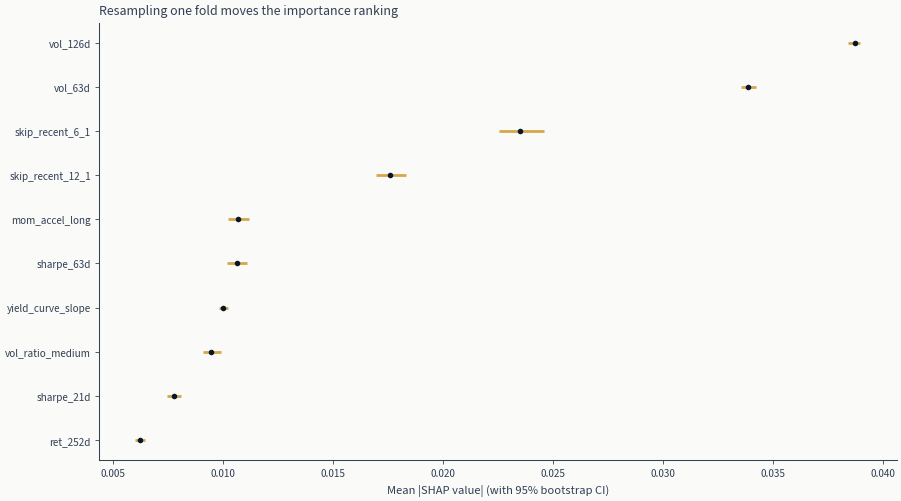

In [35]:
fig, ax = plt.subplots(figsize=(9, 5))
ypos = np.arange(TOP_K_BOOT)
ax.errorbar(
    point_estimate,
    ypos,
    xerr=[point_estimate - boot_lo, boot_hi - point_estimate],
    fmt="o",
    color=COLORS["blue"],
    ecolor=COLORS["amber"],
    elinewidth=2,
    capsize=4,
)
ax.set_yticks(ypos)
ax.set_yticklabels(top_boot)
ax.invert_yaxis()
ax.set_xlabel("Mean |SHAP value| (with 95% bootstrap CI)")
ax.set_title("Resampling one fold moves the importance ranking")
show_with_alt(
    fig,
    "Mean absolute SHAP per leading feature with a 95 percent bootstrap interval "
    "drawn as a horizontal error bar.",
)

In [36]:
lead_col = 0
diff_draws = boot_means[:, lead_col][:, None] - boot_means[:, 1:]
diff_lo = np.percentile(diff_draws, 2.5, axis=0)
diff_hi = np.percentile(diff_draws, 97.5, axis=0)

ranking = pl.DataFrame(
    {
        "against": top_boot[1:],
        "mean_gap": point_estimate[lead_col] - point_estimate[1:],
        "gap_p2.5": diff_lo,
        "gap_p97.5": diff_hi,
        "outranks": diff_lo > 0,
    }
)
print(
    f"{top_boot[lead_col]} outranks {int(ranking['outranks'].sum())} of "
    f"{ranking.height} other leading features on this fold, at 95%."
)
ranking

vol_126d outranks 9 of 9 other leading features on this fold, at 95%.


against,mean_gap,gap_p2.5,gap_p97.5,outranks
str,f64,f64,f64,bool
"""vol_63d""",0.004855,0.004634,0.005064,true
"""skip_recent_6_1""",0.015217,0.01407,0.016306,true
"""skip_recent_12_1""",0.021106,0.020175,0.021967,true
"""mom_accel_long""",0.028059,0.027553,0.028613,true
"""sharpe_63d""",0.028075,0.027381,0.028607,true
"""yield_curve_slope""",0.028702,0.028439,0.028985,true
"""vol_ratio_medium""",0.029253,0.028791,0.029739,true
"""sharpe_21d""",0.030952,0.030523,0.031416,true
"""ret_252d""",0.032514,0.031962,0.032951,true


**Interpretation**: each interval says how much that feature's own mean
$|\phi_j|$ moves when the sessions are redrawn. It does not say whether one
feature outranks another. Reading one feature's interval against a second
feature's point estimate compares two different quantities, and the two move
together across replicates - a session that lifts one lifts the other - so the
comparison ignores exactly the correlation that decides the question.

The cell below asks it directly, by bootstrapping the *difference* between the
leading feature's mean $|\phi_j|$ and each other feature's, on the same redrawn
sessions. A ranking is claimed only where that difference interval excludes
zero. This is the within-fold complement to the across-fold stability chart
above.

## Key Takeaways

1. **Linear SHAP is exact.** For Ridge regression, SHAP values equal
   $\beta_j \cdot (x_j - \bar{x}_j)$, with no approximation and no sampling.
   That makes a linear model the right place to learn the machinery, and the
   closed-form comparison above is the check to run whenever the toolchain,
   the masker or the library version changes.

2. **Read global importance as magnitude, not as evidence.** Mean $|\phi_j|$
   says how much a feature moved predictions, not whether moving them helped.
   A feature can lead the ranking while contributing nothing out of sample,
   which is why the sign check and the right-versus-wrong split follow it.

3. **Compare attribution between the calls the model got right and the ones
   it got wrong.** Attribution alone cannot distinguish them: a confident
   wrong prediction decomposes exactly as cleanly as a confident correct one.
   Splitting the high-conviction band by outcome and ranking features by the
   wrong-to-right ratio is what turns a description into a diagnosis.

4. **Distinguish the two kinds of instability, and check both per fold.**
   Importance that moves across folds is a regime story; importance that is
   uncertain within a fold is a sample-size story. The cross-fold trajectory
   answers the first and the within-fold bootstrap interval answers the
   second, and a feature can look solid on one while failing the other.

**Next**: `06_conformal_prediction` quantifies *how uncertain* each
prediction is - the natural complement to "what drives this prediction."
*Chapter 12* extends SHAP to gradient boosting via `TreeExplainer`, where
attributions capture non-linear interactions invisible to coefficient
tables.